# Model Evaluation and Improvement
Sound Realty House Price ML Model

## Train the model v1

In [21]:
import json
import pathlib
import pickle
from datetime import date
from typing import List
from typing import Tuple

import numpy
import pandas
from sklearn import model_selection
from sklearn import metrics
from sklearn import neighbors
from sklearn import pipeline
from sklearn import preprocessing

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [22]:

SALES_PATH = "../data/kc_house_data.csv"  # path to CSV with home sale data
DEMOGRAPHICS_PATH = "../data/zipcode_demographics.csv"  # path to CSV with demographics
# List of columns (subset) that will be taken from home sale data
SALES_COLUMN_SELECTION = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'zipcode'
]
OUTPUT_DIR = "../model" # Directory where output artifacts will be saved

In [23]:
def load_data(
    sales_path: str, demographics_path: str, sales_column_selection: List[str]
) -> Tuple[pandas.DataFrame, pandas.Series]:
    """Load the target and feature data by merging sales and demographics.

    Args:
        sales_path: path to CSV file with home sale data
        demographics_path: path to CSV file with demographics data
        sales_column_selection: list of columns from sales data to be used as
            features

    Returns:
        Tuple containg with two elements: a DataFrame and a Series of the same
        length.  The DataFrame contains features for machine learning, the
        series contains the target variable (home sale price).

    """
    data = pandas.read_csv(sales_path,
                           usecols=sales_column_selection,
                           dtype={'zipcode': str})
    demographics = pandas.read_csv(demographics_path,
                                   dtype={'zipcode': str})

    merged_data = data.merge(demographics, how="left",
                             on="zipcode").drop(columns="zipcode")
    # Remove the target variable from the dataframe, features will remain
    y = merged_data.pop('price')
    x = merged_data

    return x, y

In [24]:
"""Load data, train model, and export artifacts."""
x, y = load_data(SALES_PATH, DEMOGRAPHICS_PATH, SALES_COLUMN_SELECTION)
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    x, y, random_state=42)

model = pipeline.make_pipeline(preprocessing.RobustScaler(),
                                neighbors.KNeighborsRegressor()).fit(
                                    x_train, y_train)

rmse = float(numpy.sqrt(metrics.mean_squared_error(y_test, model.predict(x_test))))

# output_dir = pathlib.Path(OUTPUT_DIR)
# output_dir.mkdir(exist_ok=True)

# Output model artifacts: pickled model and JSON list of features
# pickle.dump(model, open(output_dir / "model.pkl", 'wb'))

# Output model metadata
model_type = type(model.steps[-1][1]).__name__
metadata = {
    "model_type": model_type,
    "version": "1.0.0",
    "features": list(x_train.columns),
    "training_date": date.today().isoformat(),
    "rmse": round(rmse, 2),
    "description": model_type,
}
# json.dump(metadata, open(output_dir / "model_metadata.json", 'w'), indent=4)

In [25]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

## Evaluate the model

In [26]:
import pickle
import numpy
from sklearn import model_selection, metrics

# ── Load the saved model ──────────────────────────────────────────────────────
MODEL_PATH = "../model/model.pkl"
model = pickle.load(open(MODEL_PATH, "rb"))

# ── Recreate the same train/test split used during training ──────────────────
x, y = load_data(SALES_PATH, DEMOGRAPHICS_PATH, SALES_COLUMN_SELECTION)
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    x, y, random_state=42
)

# ── Predictions ───────────────────────────────────────────────────────────────
y_train_pred = model.predict(x_train)
y_test_pred  = model.predict(x_test)

# ── Metric helper ─────────────────────────────────────────────────────────────
def regression_metrics(y_true, y_pred, label: str) -> dict:
    mae  = metrics.mean_absolute_error(y_true, y_pred)
    mse  = metrics.mean_squared_error(y_true, y_pred)
    rmse = float(numpy.sqrt(mse))
    r2   = metrics.r2_score(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  MAE  : ${mae:>15,.2f}")
    print(f"  MSE  : ${mse:>15,.2f}")
    print(f"  RMSE : ${rmse:>15,.2f}")
    print(f"  R2   :  {r2:>15.4f}")
    return {"label": label, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_metrics(y_train, y_train_pred, "Train Set")
test_metrics  = regression_metrics(y_test,  y_test_pred,  "Test Set")

# ── Overfitting check ─────────────────────────────────────────────────────────
rmse_ratio = test_metrics["RMSE"] / train_metrics["RMSE"]
r2_gap     = train_metrics["R2"]  - test_metrics["R2"]

print(f"\n{'='*45}")
print("  Overfitting Analysis")
print(f"{'='*45}")
print(f"  RMSE ratio (test/train) : {rmse_ratio:.3f}  (ideal ~1.0)")
print(f"  R2 gap     (train-test) : {r2_gap:.4f}  (ideal ~0.0)")

if rmse_ratio > 1.20 or r2_gap > 0.10:
    print("\n  WARNING: Likely OVERFITTING — test error is notably higher than train error.")
elif rmse_ratio < 0.95:
    print("\n  WARNING: Possible UNDERFITTING — train error is higher than test error.")
else:
    print("\n  OK: No strong signs of overfitting.")



  Train Set
  MAE  : $      76,232.25
  MSE  : $20,582,721,068.39
  RMSE : $     143,466.79
  R2   :           0.8414

  Test Set
  MAE  : $     102,044.70
  MSE  : $40,666,526,377.04
  RMSE : $     201,659.43
  R2   :           0.7281

  Overfitting Analysis
  RMSE ratio (test/train) : 1.406  (ideal ~1.0)
  R2 gap     (train-test) : 0.1133  (ideal ~0.0)



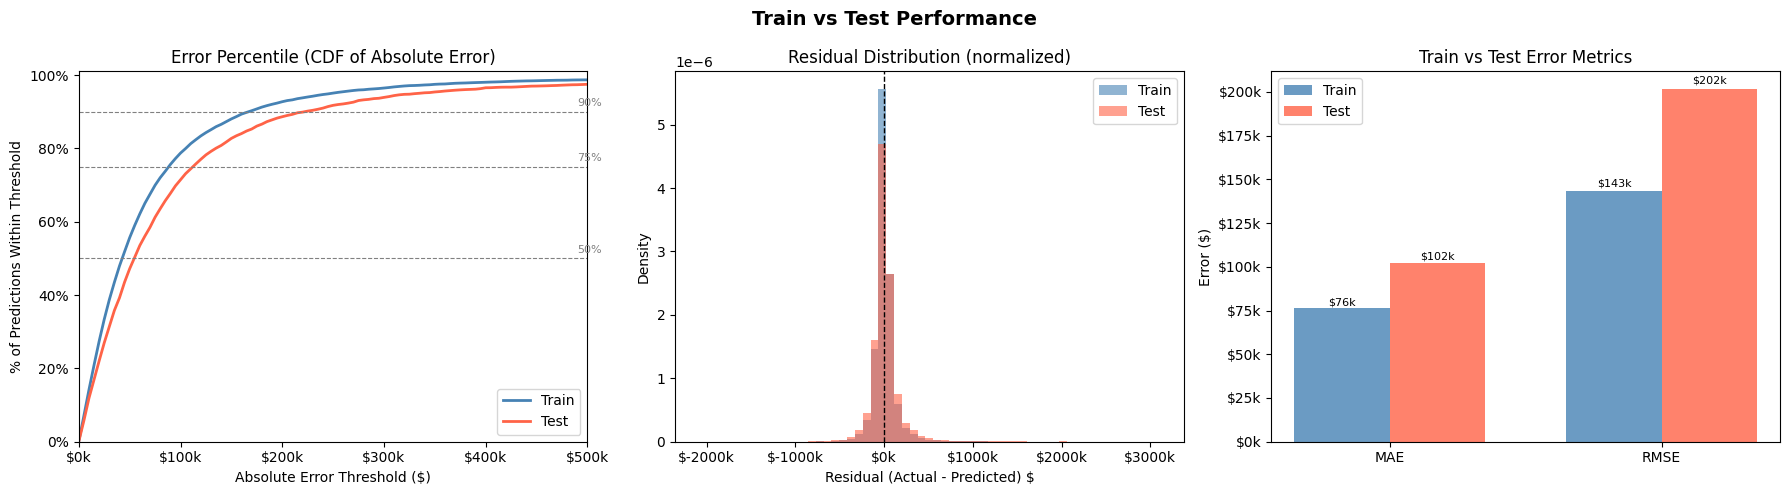

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Train vs Test Performance", fontsize=14, fontweight="bold")

# -- 1. Error Percentile Plot -----------------------------------------------
ax = axes[0]
thresholds = numpy.arange(0, 500_001, 5_000)
train_abs_err = numpy.abs(y_train - y_train_pred)
test_abs_err  = numpy.abs(y_test  - y_test_pred)
train_pct = [(train_abs_err <= t).mean() * 100 for t in thresholds]
test_pct  = [(test_abs_err  <= t).mean() * 100 for t in thresholds]
ax.plot(thresholds, train_pct, label="Train", color="steelblue", linewidth=2)
ax.plot(thresholds, test_pct,  label="Test",  color="tomato",    linewidth=2)
for pct in [50, 75, 90]:
    ax.axhline(pct, color="gray", linewidth=0.8, linestyle="--")
    ax.text(thresholds[-1] * 0.98, pct + 1, f"{pct}%", va="bottom", fontsize=8, color="gray")
ax.set_xlabel("Absolute Error Threshold ($)")
ax.set_ylabel("% of Predictions Within Threshold")
ax.set_title("Error Percentile (CDF of Absolute Error)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlim(0, thresholds[-1])
ax.set_ylim(0, 101)
ax.legend()

# -- 2. Residuals distribution (density-normalized) -------------------------
ax = axes[1]
train_residuals = y_train - y_train_pred
test_residuals  = y_test  - y_test_pred
bins = numpy.linspace(
    min(train_residuals.min(), test_residuals.min()),
    max(train_residuals.max(), test_residuals.max()),
    60,
)
ax.hist(train_residuals, bins=bins, alpha=0.6, label="Train", color="steelblue", density=True)
ax.hist(test_residuals,  bins=bins, alpha=0.6, label="Test",  color="tomato",    density=True)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Residual (Actual - Predicted) $")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution (normalized)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.legend()

# -- 3. MAE / RMSE bar comparison -------------------------------------------
ax = axes[2]
metric_names = ["MAE", "RMSE"]
train_vals = [train_metrics["MAE"], train_metrics["RMSE"]]
test_vals  = [test_metrics["MAE"],  test_metrics["RMSE"]]
x_pos = numpy.arange(len(metric_names))
width = 0.35
bars_train = ax.bar(x_pos - width / 2, train_vals, width, label="Train", color="steelblue", alpha=0.8)
bars_test  = ax.bar(x_pos + width / 2, test_vals,  width, label="Test",  color="tomato",    alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names)
ax.set_ylabel("Error ($)")
ax.set_title("Train vs Test Error Metrics")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
for bar in list(bars_train) + list(bars_test):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"${bar.get_height()/1e3:.0f}k",
        ha="center", va="bottom", fontsize=8,
    )
ax.legend()

plt.tight_layout()
plt.show()
